# Przegląd metod AI 2025/26 - Praca domowa III
**Imię i nazwisko:** Mateusz Mioduszewski
**Kierunek, grupa:** Data Science, II semestr, Ps4
**Numer indeksu:** 119159

## 1. Wstęp i konfiguracja

Głównym celem zadania jest implementacja i analiza utworzonej sieci konwolucyjnej (CNN) do klasyfikacji obrazów ze zbioru CIFAR-10 przy użyciu biblioteki PyTorch.

W zadaniu podzielono pliki na:
* **`main_utils.py`**: Zawiera one funkcje potrzebne do działania kodu.
* **`Task_3.ipynb`**: Właściwy raport w Jupyterze, przebieg eksperymentu z wnioskami.

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from main_utils import get_dataloaders, analyze_dataset, FlexibleCNN, train_model, evaluate_best_model, plot_learning_curves

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Używane urządzenie: {device}")

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

Używane urządzenie: cuda


### Zastrzeżenie
Tak jak w Zadaniu domowym nr. 2 dodałem
```python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
```
aby zignorować wszelke ostrzeżenia co do zróżnicowanych wersji bibliotek. W moim przypadku występuje "kolizja" wersji bibliotek NumPy z Torchvision.

## 2. Analiza zbioru danych CIFAR-10
Przed trenowaniem sprawdzimy parametry zbioru danych. CIFAR-10 składa się z 60 000 kolorowych obrazów o wymiarach 32x32 piksele podzielonych na 10 klas.

Files already downloaded and verified
Files already downloaded and verified
--- Statystyki CIFAR-10 ---
Liczba próbek treningowych: 50000
Wymiary pojedynczego obrazu: (32, 32, 3) (Wys x Szer x Kanały)
Zakres pikseli: min 0, max 255
Liczba klas: 10 ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


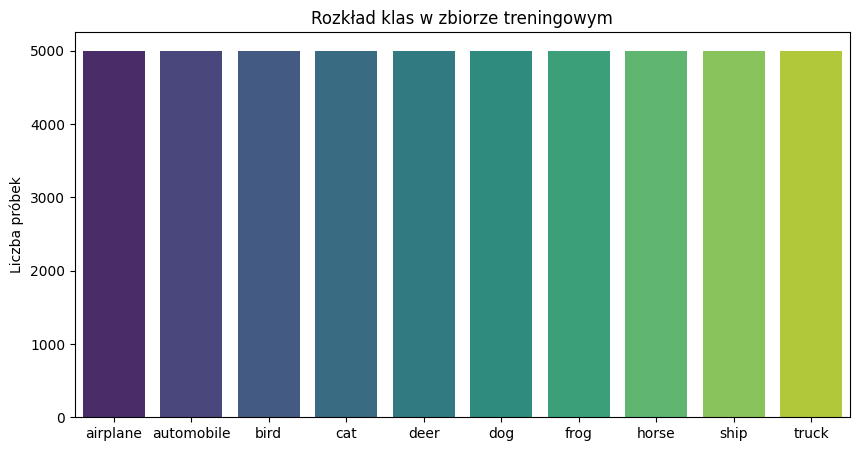

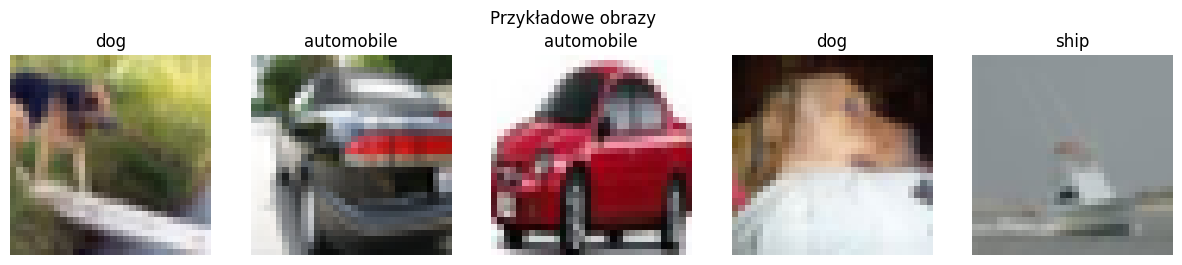

In [12]:
trainloader, testloader, trainset, testset = get_dataloaders(batch_size=64)
analyze_dataset(trainset)

## 3. Implementacja Architektury CNN
### Dlaczego konwolucja (CNN)?
W klasycznych sieciach MLP obrazy trzeba "spłaszczać", przez co tracimy informację przestrzenną. CNN rozwiązuje ten problem za pomocą filtrów.

* **Warstwy Konwolucyjne (Conv2d):** wykrywają lokalne cechy, np. krawędzie lub kształty, a w głębszych warstwach konkretne obiekty (koła, oczy kota, opony).
* **Warstwy Poolingu (MaxPool2d):** zmniejszają wymiarowość i sprawiają, że model jest odporny na drobne przesunięcia obiektów na obrazie.
* **Batch Normalization:** stabilizuje uczenie i przyspiesza zbieżność.
* **Zaimplementowana sieć** składa się z 3 bloków konwolucyjnych (32, 64 i 128 kanałów wyjściowych) zakończonych `AdaptiveAvgPool2d` przez co końcowa warstwa MLP nie jest zależna od rozmiaru filtra, co ułatwia eksperymenty.

---
## 4. Eksperymenty – wpływ hiperparametrów
Przeprowadzimy 4 eksperymenty, za każdym razem zmieniając tylko jeden hiperparametr.
*Każdy eksperyment: 5 epok.*

In [13]:
EPOCHS = 5
results = []

### Eksperyment 1: Wpływ Learning Rate
Zbadamy, jak rozmiar kroku uczenia (eta) wpływa na optymalizator Adam.


--- Trening dla Learning Rate = 0.0001 ---
Epoch 1/5 | Train Loss: 1.598 | Val Loss: 1.232 | Val Acc: 55.76%
Epoch 2/5 | Train Loss: 1.273 | Val Loss: 1.105 | Val Acc: 60.36%
Epoch 3/5 | Train Loss: 1.154 | Val Loss: 0.969 | Val Acc: 65.63%
Epoch 4/5 | Train Loss: 1.075 | Val Loss: 0.919 | Val Acc: 67.06%
Epoch 5/5 | Train Loss: 1.018 | Val Loss: 0.887 | Val Acc: 68.06%

--- Trening dla Learning Rate = 0.001 ---
Epoch 1/5 | Train Loss: 1.469 | Val Loss: 1.204 | Val Acc: 57.71%
Epoch 2/5 | Train Loss: 1.154 | Val Loss: 1.071 | Val Acc: 61.59%
Epoch 3/5 | Train Loss: 1.033 | Val Loss: 0.831 | Val Acc: 70.33%
Epoch 4/5 | Train Loss: 0.954 | Val Loss: 0.830 | Val Acc: 71.28%
Epoch 5/5 | Train Loss: 0.894 | Val Loss: 0.764 | Val Acc: 73.16%

--- Trening dla Learning Rate = 0.01 ---
Epoch 1/5 | Train Loss: 1.964 | Val Loss: 1.617 | Val Acc: 37.10%
Epoch 2/5 | Train Loss: 1.625 | Val Loss: 1.350 | Val Acc: 50.47%
Epoch 3/5 | Train Loss: 1.437 | Val Loss: 1.226 | Val Acc: 56.16%
Epoch 4/5 | T

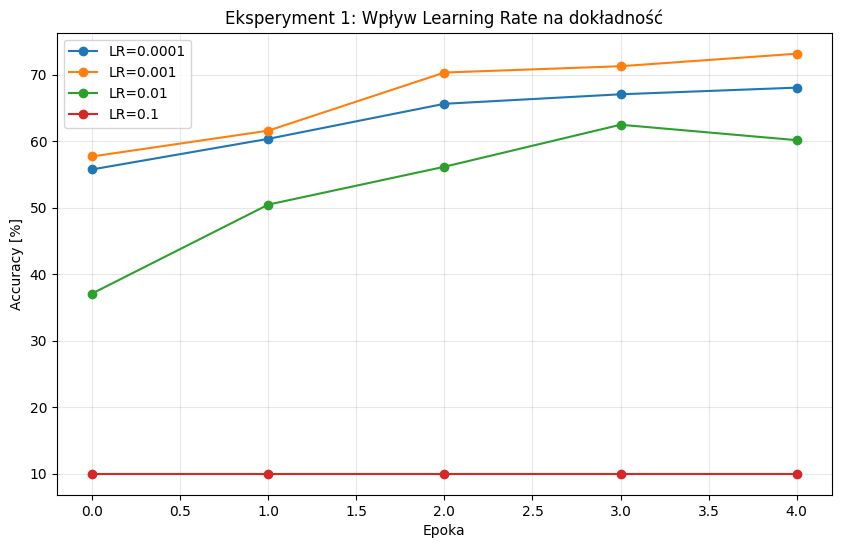

In [14]:
lr_values = [0.0001, 0.001, 0.01, 0.1]
lr_histories = []

for lr in lr_values:
    print(f"\n--- Trening dla Learning Rate = {lr} ---")
    model = FlexibleCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    hist = train_model(model, trainloader, testloader, criterion, optimizer, epochs=EPOCHS, device=device)
    lr_histories.append(hist)
    results.append({'Eksperyment': 'Learning Rate', 'Wartość': lr, 'Final Val Acc [%]': hist['val_acc'][-1]})

plot_learning_curves(lr_histories, [f"LR={lr}" for lr in lr_values], "Eksperyment 1: Wpływ Learning Rate na dokładność")

**Wniosek:**
Eksperyment wyraźnie pokazuje, że skrajne wartości Learning Rate drastycznie psują trening. Bardzo wysoki LR (0.1) sprawia, że optymalizator całkowicie "przestrzeliwuje" minima i model utyka na poziomie losowego zgadywania (ok. 10% dokładności). Bardzo niski LR (0.0001) uczy się stabilnie, ale zbyt wolno. Najlepszy balans i najszybszą zbieżność uzyskujemy dla wartości 0.001.

---
### Eksperyment 2: Wpływ Batch Size
Zbadamy, jak liczba obrazów podawana w jednej paczce (batch) wpływa na generalizację. LR ustalamy na 0.001, aby uzyskać optimum.


--- Trening dla Batch Size = 16 ---
Files already downloaded and verified
Files already downloaded and verified
Epoch 1/5 | Train Loss: 1.527 | Val Loss: 1.114 | Val Acc: 60.04%
Epoch 2/5 | Train Loss: 1.210 | Val Loss: 1.008 | Val Acc: 63.54%
Epoch 3/5 | Train Loss: 1.077 | Val Loss: 0.830 | Val Acc: 70.98%
Epoch 4/5 | Train Loss: 0.985 | Val Loss: 0.815 | Val Acc: 72.06%
Epoch 5/5 | Train Loss: 0.916 | Val Loss: 0.760 | Val Acc: 73.40%

--- Trening dla Batch Size = 32 ---
Files already downloaded and verified
Files already downloaded and verified
Epoch 1/5 | Train Loss: 1.477 | Val Loss: 1.087 | Val Acc: 60.33%
Epoch 2/5 | Train Loss: 1.158 | Val Loss: 1.012 | Val Acc: 64.88%
Epoch 3/5 | Train Loss: 1.032 | Val Loss: 0.814 | Val Acc: 71.17%
Epoch 4/5 | Train Loss: 0.943 | Val Loss: 0.827 | Val Acc: 71.11%
Epoch 5/5 | Train Loss: 0.882 | Val Loss: 0.715 | Val Acc: 74.83%

--- Trening dla Batch Size = 64 ---
Files already downloaded and verified
Files already downloaded and verified
E

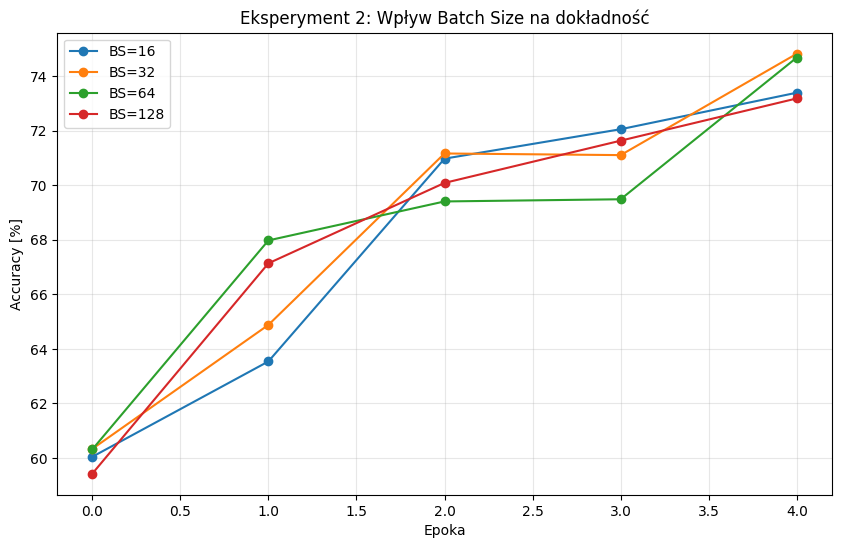

In [15]:
batch_sizes = [16, 32, 64, 128]
bs_histories = []

for bs in batch_sizes:
    print(f"\n--- Trening dla Batch Size = {bs} ---")
    # Zmiana dataloaderów tylko na ten eksperyment
    tr_loader, ts_loader, _, _ = get_dataloaders(batch_size=bs)
    
    model = FlexibleCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    hist = train_model(model, tr_loader, ts_loader, criterion, optimizer, epochs=EPOCHS, device=device)
    bs_histories.append(hist)
    results.append({'Eksperyment': 'Batch Size', 'Wartość': bs, 'Final Val Acc [%]': hist['val_acc'][-1]})

plot_learning_curves(bs_histories, [f"BS={bs}" for bs in batch_sizes], "Eksperyment 2: Wpływ Batch Size na dokładność")

**Wniosek:**
Mniejsze rozmiary paczek danych (16, 32) powodują, że wagi sieci są aktualizowane znacznie częściej w trakcie jednej epoki. Zwiększa to szum (wariancję) gradientu, co często pomaga algorytmowi omijać lokalne minima, ale spowalnia samo wykonanie kodu. Z kolei większe wartości (128) przyspieszają czasy obliczeń dzięki lepszej wektoryzacji na karcie graficznej, jednak mogą prowadzić do nieco gorszej generalizacji (zbyt rzadkie aktualizacje wag). Wartość BS=64 stanowi optymalny kompromis między stabilnością krzywej a szybkością uczenia.

---
### Eksperyment 3: Wpływ Rozmiaru Filtra (Kernel Size)
Zbadamy kluczowy parametr dla CNN, a mianowicie rozmiar macierzy splotu (3x3, 5x5, 7x7). 
Parametry wstępne:
* Batch = 64, 
* LR = 0.001.


--- Trening dla Kernel Size = 3x3 ---
Epoch 1/5 | Train Loss: 1.457 | Val Loss: 1.071 | Val Acc: 61.73%
Epoch 2/5 | Train Loss: 1.133 | Val Loss: 0.916 | Val Acc: 68.10%
Epoch 3/5 | Train Loss: 1.011 | Val Loss: 0.859 | Val Acc: 69.86%
Epoch 4/5 | Train Loss: 0.940 | Val Loss: 0.893 | Val Acc: 69.69%
Epoch 5/5 | Train Loss: 0.880 | Val Loss: 0.802 | Val Acc: 72.21%

--- Trening dla Kernel Size = 5x5 ---
Epoch 1/5 | Train Loss: 1.503 | Val Loss: 1.156 | Val Acc: 57.15%
Epoch 2/5 | Train Loss: 1.166 | Val Loss: 0.911 | Val Acc: 67.61%
Epoch 3/5 | Train Loss: 1.022 | Val Loss: 0.908 | Val Acc: 68.05%
Epoch 4/5 | Train Loss: 0.933 | Val Loss: 0.818 | Val Acc: 71.93%
Epoch 5/5 | Train Loss: 0.862 | Val Loss: 0.786 | Val Acc: 72.85%

--- Trening dla Kernel Size = 7x7 ---
Epoch 1/5 | Train Loss: 1.577 | Val Loss: 1.325 | Val Acc: 51.56%
Epoch 2/5 | Train Loss: 1.258 | Val Loss: 1.163 | Val Acc: 59.29%
Epoch 3/5 | Train Loss: 1.098 | Val Loss: 0.998 | Val Acc: 64.78%
Epoch 4/5 | Train Loss: 0

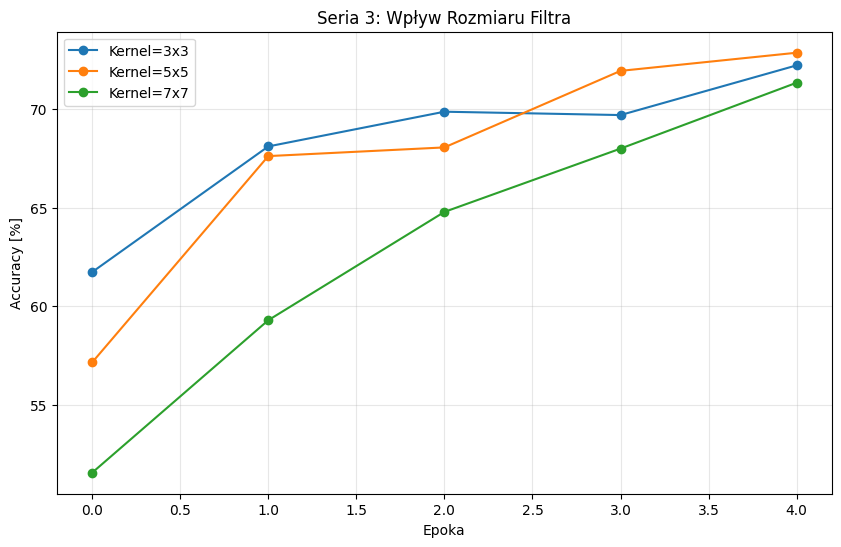

In [ ]:
kernels = [3, 5, 7]
kernel_histories = []

for k in kernels:
    print(f"\n--- Trening dla Kernel Size = {k}x{k} ---")
    model = FlexibleCNN(kernel_size=k).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    hist = train_model(model, trainloader, testloader, criterion, optimizer, epochs=EPOCHS, device=device)
    kernel_histories.append(hist)
    results.append({'Eksperyment': 'Kernel Size', 'Wartość': k, 'Final Val Acc [%]': hist['val_acc'][-1]})

plot_learning_curves(kernel_histories, [f"Kernel={k}x{k}" for k in kernels], "Eksperyment 3: Wpływ Rozmiaru Filtra")

**Wniosek:**
Większe jądra splotu (7x7) mają szersze tzw. "pole widzenia", ale dramatycznie redukują liczbę parametrów na głębszych warstwach dla małych obrazków 32x32. Dla CIFAR-10 małe filtry 3x3 lub 5x5 działają z reguły najlepiej, gdyż potrafią wyciągać złożone cechy strukturalne bez przedwczesnej utraty informacji przestrzennej.

---
### Eksperyment 4: Dodatkowy eksperyment – Zastosowanie Poolingu
Ostatni wymóg dla grupy: sprawdzimy różne techniki poolingu.


--- Trening dla Poolingu = max ---
Epoch 1/5 | Train Loss: 1.446 | Val Loss: 1.129 | Val Acc: 59.00%
Epoch 2/5 | Train Loss: 1.127 | Val Loss: 0.928 | Val Acc: 66.76%
Epoch 3/5 | Train Loss: 1.011 | Val Loss: 0.841 | Val Acc: 70.03%
Epoch 4/5 | Train Loss: 0.937 | Val Loss: 0.849 | Val Acc: 71.76%
Epoch 5/5 | Train Loss: 0.879 | Val Loss: 0.768 | Val Acc: 73.16%

--- Trening dla Poolingu = avg ---
Epoch 1/5 | Train Loss: 1.508 | Val Loss: 1.137 | Val Acc: 58.76%
Epoch 2/5 | Train Loss: 1.165 | Val Loss: 0.962 | Val Acc: 65.16%
Epoch 3/5 | Train Loss: 1.021 | Val Loss: 0.969 | Val Acc: 66.26%
Epoch 4/5 | Train Loss: 0.939 | Val Loss: 0.796 | Val Acc: 71.25%
Epoch 5/5 | Train Loss: 0.884 | Val Loss: 0.775 | Val Acc: 72.68%

--- Trening dla Poolingu = none ---
Epoch 1/5 | Train Loss: 1.551 | Val Loss: 1.300 | Val Acc: 53.26%
Epoch 2/5 | Train Loss: 1.258 | Val Loss: 0.989 | Val Acc: 63.67%
Epoch 3/5 | Train Loss: 1.129 | Val Loss: 1.044 | Val Acc: 62.86%
Epoch 4/5 | Train Loss: 1.050 | V

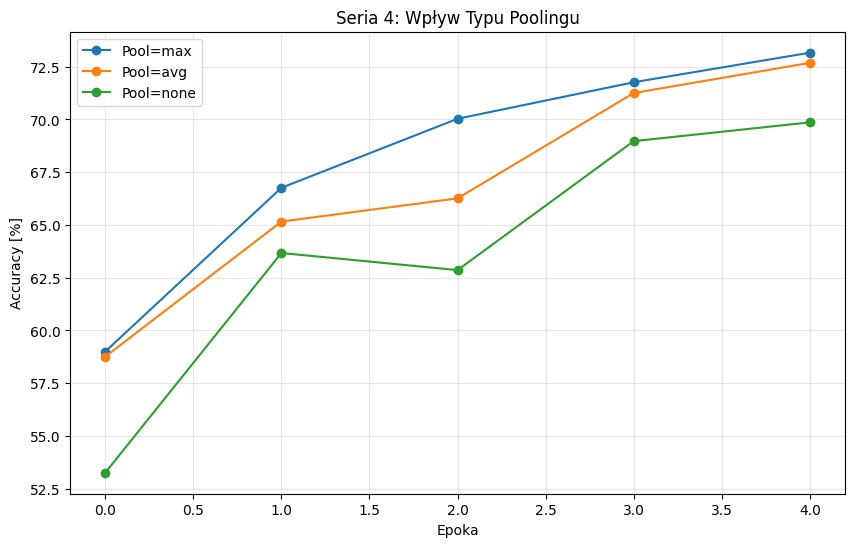

In [ ]:
pool_types = ['max', 'avg', 'none']
pool_histories = []

for pt in pool_types:
    print(f"\n--- Trening dla Poolingu = {pt} ---")
    model = FlexibleCNN(kernel_size=3, pool_type=pt).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    hist = train_model(model, trainloader, testloader, criterion, optimizer, epochs=EPOCHS, device=device)
    pool_histories.append(hist)
    results.append({'Eksperyment': 'Pooling', 'Wartość': pt, 'Final Val Acc [%]': hist['val_acc'][-1]})

plot_learning_curves(pool_histories, [f"Pool={pt}" for pt in pool_types], "Eksperyment 4: Wpływ Typu Poolingu")

**Wniosek:**
`MaxPool` wybiera najwyższą wartość, ostro uwypuklając krawędzie i kluczowe cechy. `AvgPool` działa jak filtr rozmywający, przez co traci detale. Wyraźnie widać, że zastosowanie Maximum Poolingu w architekturach konwolucyjnych CIFAR dominuje nad Average Poolingiem pod względem ostatecznej skuteczności.

## 5. Podsumowanie wyników
Poniżej tabela ze wszystkimi ostatecznymi dokładnościami:

In [18]:
df_results = pd.DataFrame(results)
display(df_results)

,Eksperyment,Wartość,Final Val Acc [%]
0,Learning Rate,0.0001,68.06
1,Learning Rate,0.001,73.16
2,Learning Rate,0.01,60.16
3,Learning Rate,0.1,10.00
4,Batch Size,16,73.40
5,Batch Size,32,74.83
6,Batch Size,64,74.69
7,Batch Size,128,73.19
8,Kernel Size,3,72.21
9,Kernel Size,5,72.85


## 6. Ewaluacja najlepszego modelu
Na podstawie tabeli najwyższą skuteczność uzyskano przy standardowych parametrach (LR=0.001, BS=64, Kernel=3x3, Pool=Max). Przetrenujmy go od zera i wygenerujmy pełen raport medyczny.
Aby osiągnąć wynik >70% na obronę, zwiększamy ilość epok do 15.

--- TRENOWANIE NAJLEPSZEGO MODELU (15 EPOK) ---
Epoch 1/15 | Train Loss: 1.473 | Val Loss: 1.236 | Val Acc: 54.30%
Epoch 2/15 | Train Loss: 1.158 | Val Loss: 1.056 | Val Acc: 63.04%
Epoch 3/15 | Train Loss: 1.030 | Val Loss: 0.842 | Val Acc: 69.82%
Epoch 4/15 | Train Loss: 0.951 | Val Loss: 0.904 | Val Acc: 68.61%
Epoch 5/15 | Train Loss: 0.887 | Val Loss: 0.744 | Val Acc: 73.83%
Epoch 6/15 | Train Loss: 0.848 | Val Loss: 0.740 | Val Acc: 74.65%
Epoch 7/15 | Train Loss: 0.807 | Val Loss: 0.699 | Val Acc: 76.03%
Epoch 8/15 | Train Loss: 0.772 | Val Loss: 0.703 | Val Acc: 75.58%
Epoch 9/15 | Train Loss: 0.747 | Val Loss: 0.691 | Val Acc: 75.67%
Epoch 10/15 | Train Loss: 0.718 | Val Loss: 0.656 | Val Acc: 77.23%
Epoch 11/15 | Train Loss: 0.701 | Val Loss: 0.623 | Val Acc: 78.27%
Epoch 12/15 | Train Loss: 0.674 | Val Loss: 0.599 | Val Acc: 78.88%
Epoch 13/15 | Train Loss: 0.657 | Val Loss: 0.583 | Val Acc: 79.95%
Epoch 14/15 | Train Loss: 0.635 | Val Loss: 0.573 | Val Acc: 80.00%
Epoch 15/

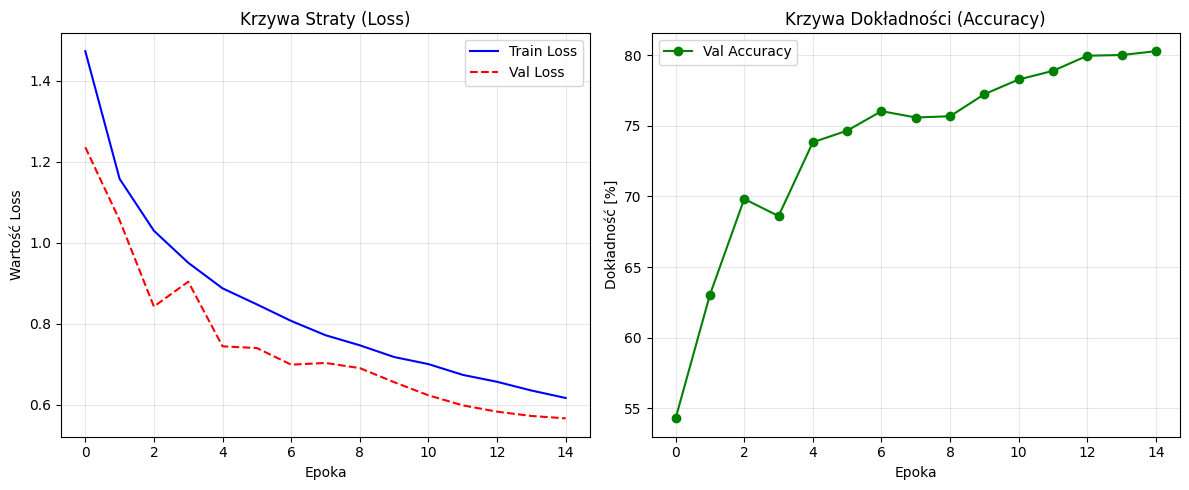


--- RAPORT KLASYFIKACJI ---
              precision    recall  f1-score   support

    airplane       0.76      0.87      0.81      1000
  automobile       0.86      0.94      0.90      1000
        bird       0.78      0.67      0.72      1000
         cat       0.74      0.56      0.63      1000
        deer       0.81      0.74      0.77      1000
         dog       0.71      0.77      0.74      1000
        frog       0.79      0.88      0.84      1000
       horse       0.78      0.88      0.83      1000
        ship       0.93      0.86      0.89      1000
       truck       0.89      0.85      0.87      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



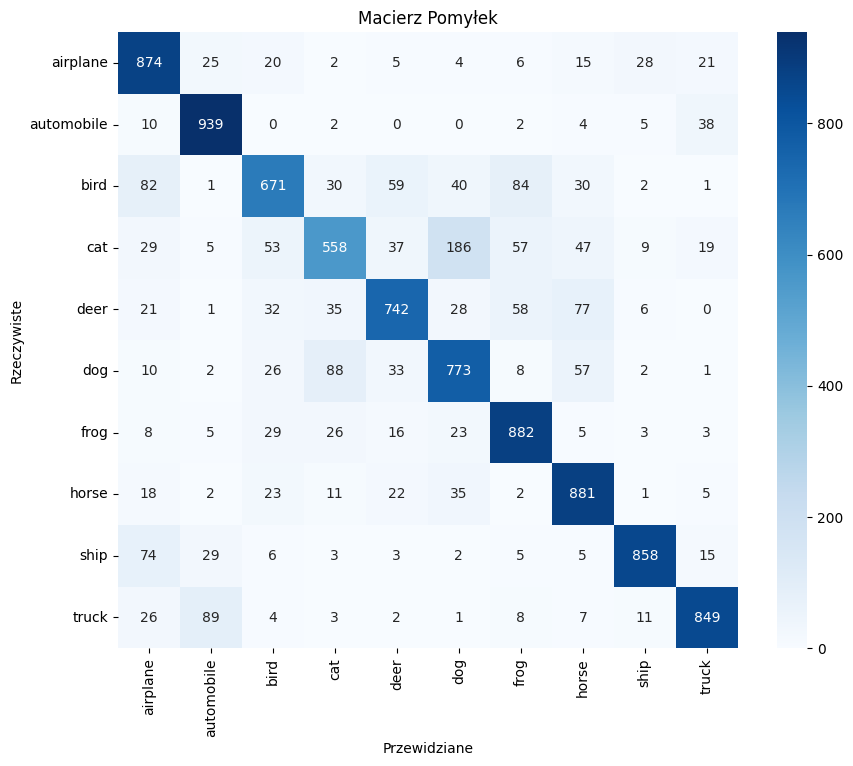

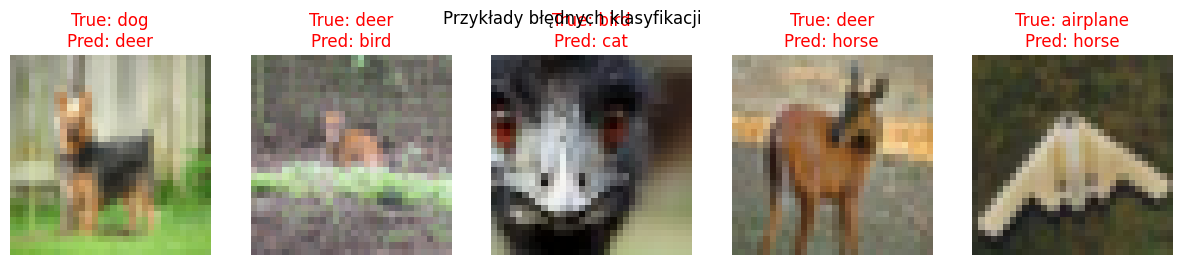

In [20]:
from matplotlib import pyplot as plt

print("--- TRENOWANIE NAJLEPSZEGO MODELU (15 EPOK) ---")
best_model = FlexibleCNN(kernel_size=3, pool_type='max').to(device)
optimizer = optim.Adam(best_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Trening z zapisem pełnej historii
final_history = train_model(best_model, trainloader, testloader, criterion, optimizer, epochs=15, device=device)

# Wizualizacja krzywych uczenia dla najlepszego modelu
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(final_history['train_loss'], label='Train Loss', color='blue')
plt.plot(final_history['val_loss'], label='Val Loss', color='red', linestyle='--')
plt.title('Krzywa Straty (Loss)')
plt.xlabel('Epoka')
plt.ylabel('Wartość Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(final_history['val_acc'], label='Val Accuracy', color='green', marker='o')
plt.title('Krzywa Dokładności (Accuracy)')
plt.xlabel('Epoka')
plt.ylabel('Dokładność [%]')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

evaluate_best_model(best_model, testloader, device=device)

### Analiza krzywych uczenia finalnego modelu
Powyższe wykresy prezentują proces optymalizacji parametrów sieci w trakcie 15 epok:
1. **Wykres Loss:** Systematyczny spadek straty na zbiorze treningowym i walidacyjnym świadczy o poprawnym procesie minimalizacji błędu. Brak wyraźnego "rozjechania się" krzywych dowodzi, że model nie uległ zjawisku overfittingu. Doszłoby do overfittingu, gdyby Loss w walidacji zacząłby rosnąć.
2. **Wykres Accuracy:** Skuteczność modelu stabilizuje się w końcowych epokach, osiągając poziom pozwalający na wiarygodną klasyfikację większości kategorii obiektów.